This is meant to synthesize all of the steps of the full parsing pipeline for each page.

# Imports

In [104]:
from ultralytics import YOLO
from ultralytics.utils.ops import xyxy2xywh, xywh2xyxy 
from pathlib import Path
import random
import os
import cv2
import numpy as np
from matplotlib import pyplot as plt
from anytree import Node, RenderTree, PreOrderIter
import seaborn as sns
from sklearn.cluster import DBSCAN
from collections import namedtuple
from transformers import pipeline
from PIL import Image
import re

# Pipeline

## Inputs 

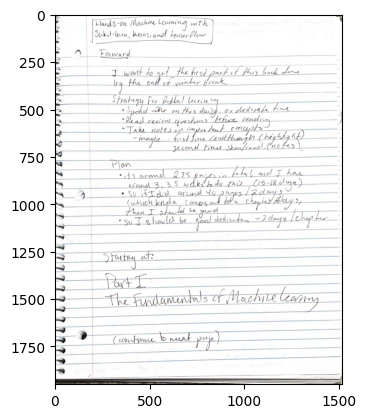

In [66]:
test_image_path = r"datasets\large-section-dataset\data\images\train\note-transfer ch1-6_Page_01_Image_0001.jpg"
test_image = cv2.imread(test_image_path, cv2.IMREAD_ANYCOLOR)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
plt.imshow(test_image)

## Segmentation

### Functions

In [67]:
# Takes xywhr and makes sure that it isn't the wrong angle
def normalize_xywhr(xywhr):
    x_center, y_center, width, height, theta = xywhr.tolist()
    if theta > (1/4)*np.pi or theta < (-1/4)*np.pi:
        temp = width
        width = height
        height = temp
        theta -= np.sign(theta)*(np.pi/2)

    return np.array([x_center, y_center, width, height, theta])

In [68]:
# Takes image and crop vars, returns cropped image
def crop_from_obb(image, xywhr):
    xywhr = normalize_xywhr(xywhr)
    x_center, y_center, width, height, theta = xywhr.tolist()

    # Transformation for rotation, rotate image
    rotation_matrix = cv2.getRotationMatrix2D((x_center, y_center), np.degrees(theta), 1.0)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (image.shape[1], image.shape[0]))

    # Crop the rotated image
    x_corner, y_corner = int(x_center - width/2), int(y_center - height/2)
    cropped_image = rotated_image[y_corner:y_corner+int(height), x_corner:x_corner+int(width)]

    return cropped_image

In [69]:
# Takes image and normal bounding box (no rotation) bounds (top left, bottom right points)
# Returns the cropped image
def crop_from_bb(image, xyxy):
    x1, y1, x2, y2 = xyxy.tolist()
    x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
    return image[y1:y2+1, x1:x2+1]

In [70]:
def normalize_box(xywhr):
    x, y, w, h, r = xywhr
    if r > np.pi/4:
        w, h = h, w
        r -= np.pi/2
    return x, y, w, h, r

In [71]:
def xywhr2corner(xywhr):
    x, y, w, h, r = xywhr[0], xywhr[1], xywhr[2], xywhr[3], xywhr[4]

    x = x - 0.5*w*np.cos(r) + 0.5*h*np.sin(r)
    y = y - 0.5*w*np.sin(r) - 0.5*h*np.cos(r)

    return x, y

In [72]:
def get_page_segmentations(image, section_model, line_model):
    segmentations = []
    sid = 0

    section_result = section_model.predict(image, iou=0.5, agnostic_nms=True)
    if section_result is None or len(section_result) == 0:
        print('No result!')
    section_result = section_result[0]
    if section_result.obb is None:
        print('No OBB!')

    for class_id, xywhr in sorted(list(zip(section_result.obb.cls, section_result.obb.xywhr)), key=lambda res: res[1][1]):
        # First step is the section
        cropped_image = crop_from_obb(image, xywhr)

        if cropped_image.shape[0] == 0 or cropped_image.shape[1] == 0:
            print(f'Incompatible crop: {cropped_image.shape}')
            continue

        sec_class_name = section_result.names[int(class_id)]
        xywhr = normalize_box(xywhr.cpu().tolist())
        x, y = xywhr2corner(xywhr)
        sec_node = Node(
            sec_class_name,
            id=sid,
            is_section=True,
            cls_id=int(class_id.cpu()),
            x=x,
            y=y,
            x_c=xywhr[0],
            y_c=xywhr[1],
            w=xywhr[2],
            h=xywhr[3],
            r=xywhr[4]
        )
        segmentations.append(sec_node)
        sid += 1

        # Then segment by line after each section
        line_result = line_model.predict(cropped_image, iou=0.4, agnostic_nms=True)

        if line_result is None or len(line_result) == 0:
            print('No line result!')
        line_result = line_result[0]
        if line_result.boxes is None:
            print('No boxes!')

        for class_id, xyxy in sorted(list(zip(line_result.boxes.cls, line_result.boxes.xyxy)), key=lambda x: x[1][1]): # Sorted by height
            cropped_line = crop_from_bb(cropped_image, xyxy)
            if cropped_line.shape[0] == 0 or cropped_line.shape[1] == 0:
                print(f'Incompatible crop: {cropped_line.shape}')
                continue
            
            line_class_name = line_result.names[int(class_id)]
            xywhr = xyxy2xywh(xyxy).cpu().tolist()
            xywhr.append(0)
            xywhr = normalize_box(xywhr)
            x, y = xywhr2corner(xywhr)
            line_node = Node(
                line_class_name,
                id=sid,
                is_section=False,
                cls_id=int(class_id.cpu()),
                img=cropped_line,
                x=x,
                y=y,
                x_c=xywhr[0],
                y_c=xywhr[1],
                w=xywhr[2],
                h=xywhr[3],
                r=xywhr[3]
            )
            segmentations.append(line_node)
            sid += 1

    return segmentations 

### Usage

In [73]:
section_model = YOLO(r"runs\refining-two-step\large-section-12-31\first_train\weights\best.pt")
line_model = YOLO(r"runs\refining-two-step\by-line-12-19\train\weights\best.pt")

In [74]:
segmentations = get_page_segmentations(
    image=test_image, 
    section_model=section_model, 
    line_model=line_model
)


0: 1024x800 2 Headers, 5 Sections, 57.7ms
Speed: 8.6ms preprocess, 57.7ms inference, 3.8ms postprocess per image at shape (1, 3, 1024, 800)

0: 160x640 2 Texts, 13.8ms
Speed: 1.3ms preprocess, 13.8ms inference, 1.1ms postprocess per image at shape (1, 3, 160, 640)

0: 320x640 1 Text, 39.8ms
Speed: 1.6ms preprocess, 39.8ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)

0: 96x640 2 Texts, 15.2ms
Speed: 1.2ms preprocess, 15.2ms inference, 1.9ms postprocess per image at shape (1, 3, 96, 640)

0: 192x640 4 Unordered Bullets, 6 Texts, 14.4ms
Speed: 1.7ms preprocess, 14.4ms inference, 1.2ms postprocess per image at shape (1, 3, 192, 640)

0: 224x640 3 Unordered Bullets, 6 Texts, 10.5ms
Speed: 1.7ms preprocess, 10.5ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 640)

0: 224x640 2 Texts, 9.8ms
Speed: 1.5ms preprocess, 9.8ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 640)

0: 96x640 1 Text, 7.6ms
Speed: 1.2ms preprocess, 7.6ms inference, 1.0ms

Section - (210.8,3.33) - 0.0
 - Text - (0.0,8.12)


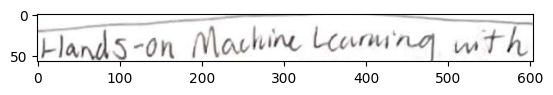

 - Text - (0.31,70.43)


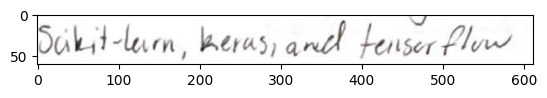

Header - (227.19,170.94) - 0.0
 - Text - (2.85,0.5)


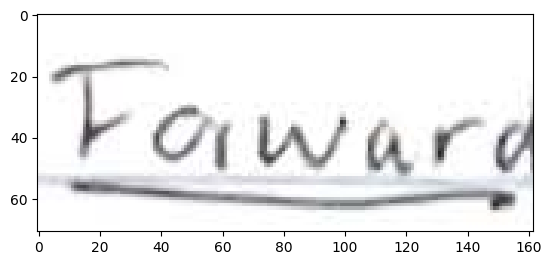

Section - (260.68,281.24) - -0.02
 - Text - (26.54,6.96)


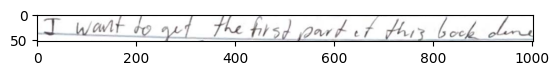

 - Text - (22.26,56.72)


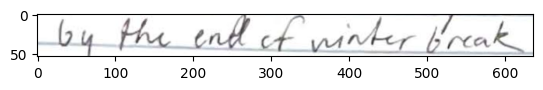

Section - (313.57,428.5) - -0.01
 - Text - (17.47,4.43)


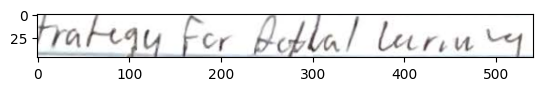

 - Unordered Bullet - (33.15,49.4)


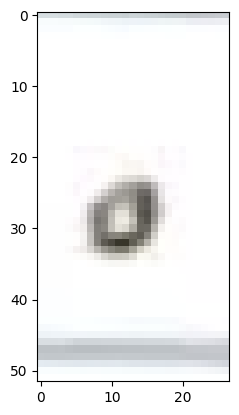

 - Text - (56.28,52.14)


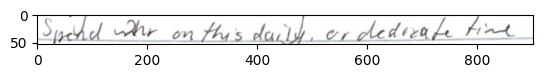

 - Unordered Bullet - (32.76,98.21)


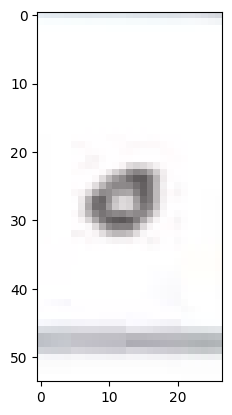

 - Text - (51.08,103.47)


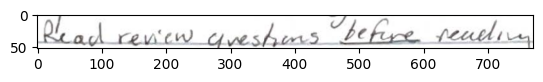

 - Unordered Bullet - (31.59,148.6)


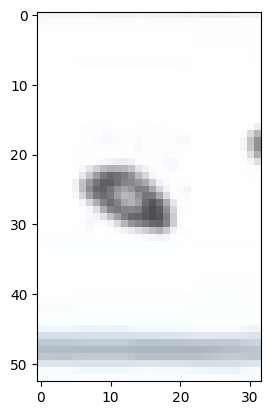

 - Text - (41.93,151.63)


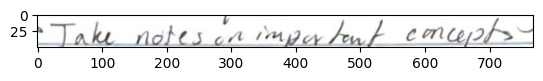

 - Text - (86.2,196.77)


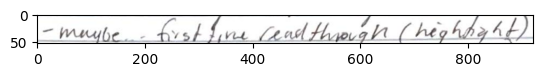

 - Unordered Bullet - (87.91,199.24)


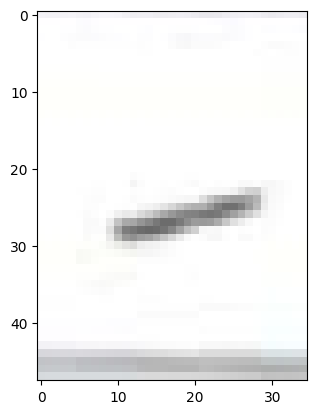

 - Text - (300.53,247.71)


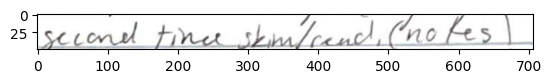

Section - (328.68,816.64) - -0.02
 - Unordered Bullet - (1.16,5.25)


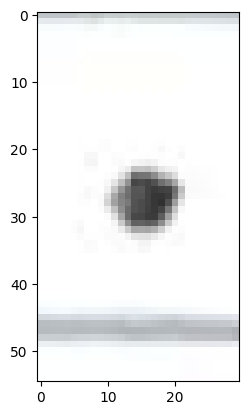

 - Text - (72.67,8.44)


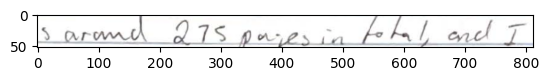

 - Text - (17.49,56.8)


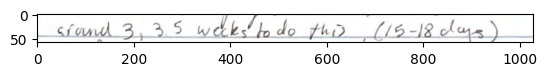

 - Unordered Bullet - (5.55,103.56)


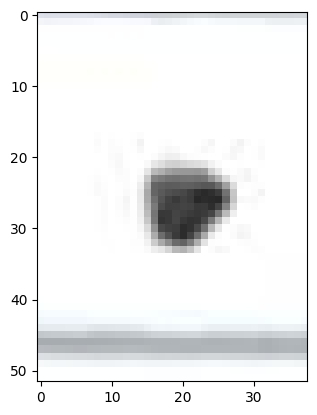

 - Text - (36.7,108.07)


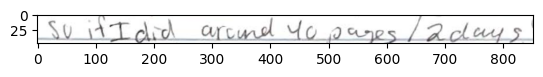

 - Text - (18.39,155.22)


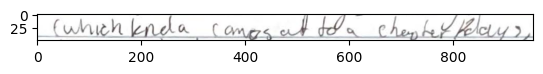

 - Text - (4.72,201.94)


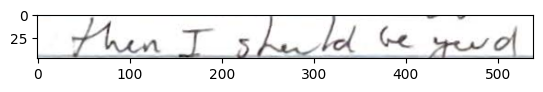

 - Text - (1.22,247.29)


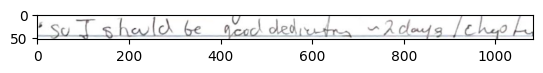

 - Unordered Bullet - (0.0,249.14)


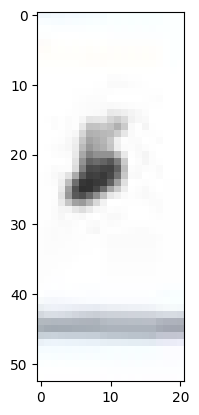

Header - (255.37,1242.91) - -0.02
 - Text - (0.1,9.55)


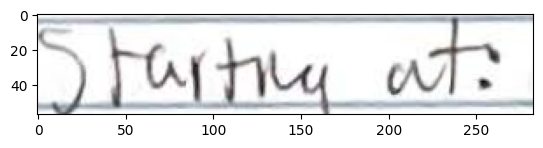

 - Text - (0.55,63.45)


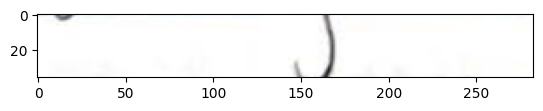

Section - (271.7,1447.97) - -0.03
 - Text - (0.0,2.98)


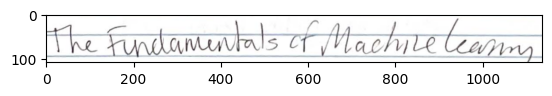

In [75]:
%matplotlib inline
for node in segmentations:
    if node.is_section:
        print(f"{node.name} - ({round(node.x,2)},{round(node.y,2)}) - {round(node.r, 2)}")
    else:
        print(f" - {node.name} - ({round(node.x,2)},{round(node.y,2)})")
        plt.imshow(node.img)
        plt.show()

## Parsing Structure

### Functions

In [34]:
# Assuming already sorted
def gap_cluster(x, gap):
    labels = np.zeros(len(x), dtype=int)
    cluster = 0

    for i in range(1, len(x)):
        if x[i] - x[i-1] > gap:
            cluster += 1
        labels[i] = cluster

    return labels

In [35]:
# Finds pairs in already sorted valeus, helps with matching bullet and text
def find_pairs(values):
    if len(values) < 2:
        return [0]

    diffs = np.diff(values)
    if len(diffs) > 1:
        lower, upper = diffs.mean() - 2*diffs.std(), diffs.mean() + 2*diffs.std()
        diffs = diffs[(diffs > lower) & (diffs < upper)]
    gap = (diffs.min() + diffs.max())/2

    values = values.reshape((-1, 1))
    labels = gap_cluster(values, gap)
    return labels

In [36]:
def find_clusters(values):
    if len(values) < 2:
        return [0]

    diffs = np.diff(sorted(values))
    if len(diffs) > 1:
        lower, upper = diffs.mean() - 2*diffs.std(), diffs.mean() + 2*diffs.std()
        diffs = diffs[(diffs > lower) & (diffs < upper)]
    else:
        return [0,0]
    gap = (diffs.min() + diffs.max())/2

    values = values.reshape((-1, 1))
    labels = DBSCAN(eps=gap, min_samples=1).fit_predict(values)
    return labels

For parsing, will have to figure out class labels and ids, for now its:

large-sections

0. Header
1. Section

by-line

0. None
1. Unordered Bullet
2. Ordered Bullet
3. Text
4. Figure

In [37]:
Entry = namedtuple('Entry', ['node', 'level'])

In [38]:
def is_bullet(node):
    return node.cls_id == 1 or node.cls_id == 2

In [39]:
def is_text(node):
    return node.cls_id == 3

In [40]:
def parse_section(parent, nodes):
    y_values = np.array([node.y for node in nodes])
    vertical_labels = find_pairs(y_values)

    x_values = np.array([node.x for node in nodes])
    text_xs = np.array([[node.x, i] for i, node in enumerate(nodes) if is_text(node)])
    if len(text_xs) == 0:
        return
    horizontal_text_labels = find_clusters(text_xs[:, 0])

    horizontal_labels = np.zeros(len(nodes))
    horizontal_labels[text_xs[:, 1].astype(int)] = horizontal_text_labels

    parents = [Entry(parent, -1)]

    for i in range(len(nodes)):
        if i != len(nodes)-1 and vertical_labels[i] == vertical_labels[i+1]:
            horizontal_labels[i] = max(horizontal_labels[i], horizontal_labels[i+1])
            horizontal_labels[i+1] = max(horizontal_labels[i], horizontal_labels[i+1])

        # Flip bullet and text if text comes first
        if (i != len(nodes)-1 and 
            is_text(nodes[i]) and 
            is_bullet(nodes[i+1]) and
            vertical_labels[i] == vertical_labels[i+1]):

            temp = nodes[i]
            nodes[i] = nodes[i+1]
            nodes[i+1] = temp

        node = nodes[i]
        if is_text(node):
            while (horizontal_labels[i] < parents[-1].level):
                parents.pop()
            node.parent = parents[-1].node
        else:   
            while (horizontal_labels[i] <= parents[-1].level):
                parents.pop()
            node.parent = parents[-1].node

        if is_bullet(node):
            parents.append(Entry(node, horizontal_labels[i]))

In [41]:
def get_average_angle(nodes):
    sum_r = 0
    for node in nodes:
        sum_r += node.r
    avg_r = sum_r / len(nodes) 
    return avg_r

In [42]:
def correct_node_corners(nodes, center):
    x_values = [node.x for node in nodes]
    y_values = [node.y for node in nodes]

    xy = np.array([x_values, y_values]).T
    angle = get_average_angle(nodes)
    rot = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    return (xy - center) @ rot.T + center

In [43]:
def parse_page(root, nodes, width, height):
    sections = [node for node in nodes if node.is_section]
    indices = [i for i in range(len(nodes)) if nodes[i].is_section] + [len(nodes)]

    xy = correct_node_corners(sections,  (width/2, height/2))
    levels = find_clusters(xy[:, 0])
    
    parents = [Entry(root, -1)]
    for i, (node, level, index) in enumerate(zip(sections, levels, indices)):
        while level <= parents[-1].level:
            parents.pop()
        
        node.parent = parents[-1].node
        parents.append(Entry(node, level))

        parse_section(node, nodes[index+1:indices[i+1]])

### Usage

In [76]:
root = Node("Root", cls_id=-1, is_section=True)
parse_page(root, segmentations, test_image.shape[0], test_image.shape[1])

In [77]:
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")

Root
├── Section
│   ├── Text
│   └── Text
└── Header
    ├── Text
    ├── Section
    │   ├── Text
    │   ├── Text
    │   ├── Section
    │   │   ├── Text
    │   │   ├── Unordered Bullet
    │   │   │   └── Text
    │   │   ├── Unordered Bullet
    │   │   │   └── Text
    │   │   ├── Unordered Bullet
    │   │   │   └── Text
    │   │   └── Unordered Bullet
    │   │       ├── Text
    │   │       └── Text
    │   └── Section
    │       └── Unordered Bullet
    │           ├── Text
    │           ├── Text
    │           ├── Unordered Bullet
    │           │   ├── Text
    │           │   ├── Text
    │           │   └── Text
    │           └── Unordered Bullet
    │               └── Text
    ├── Header
    │   ├── Text
    │   └── Text
    └── Section
        └── Text


Root
├── Section
│   ├── Text


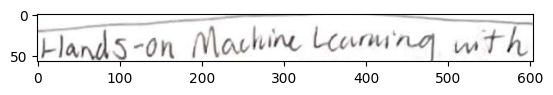

│   └── Text


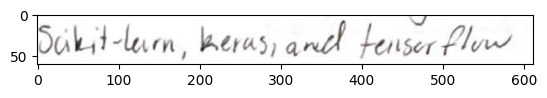

└── Header
    ├── Text


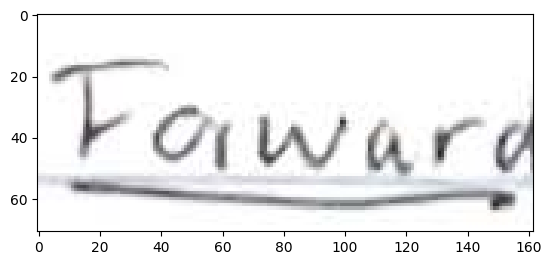

    ├── Section
    │   ├── Text


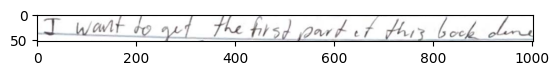

    │   ├── Text


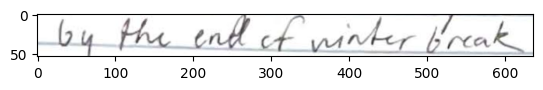

    │   ├── Section
    │   │   ├── Text


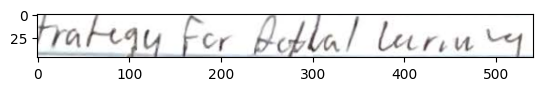

    │   │   ├── Unordered Bullet


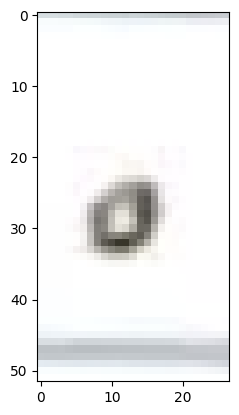

    │   │   │   └── Text


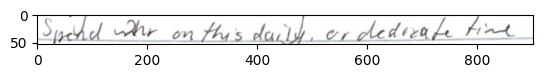

    │   │   ├── Unordered Bullet


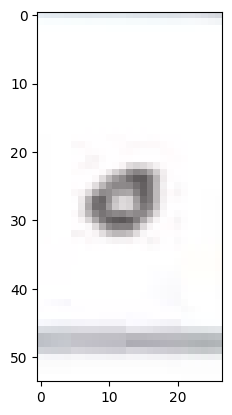

    │   │   │   └── Text


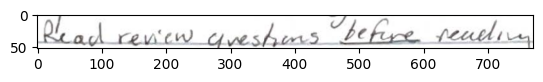

    │   │   ├── Unordered Bullet


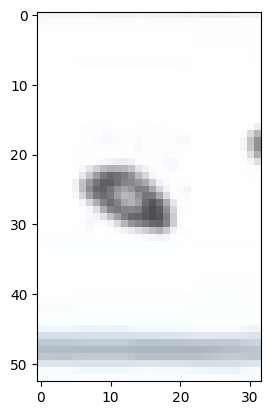

    │   │   │   └── Text


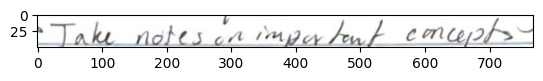

    │   │   └── Unordered Bullet


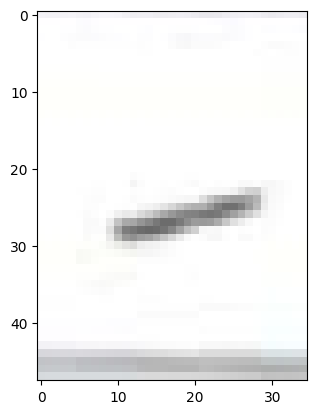

    │   │       ├── Text


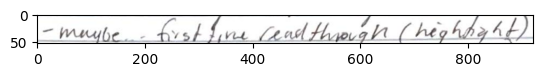

    │   │       └── Text


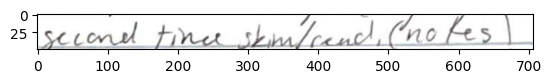

    │   └── Section
    │       └── Unordered Bullet


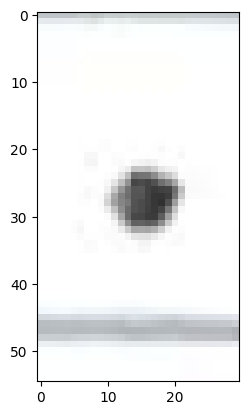

    │           ├── Text


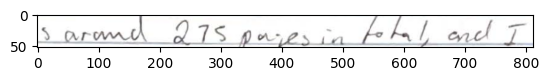

    │           ├── Text


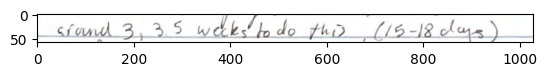

    │           ├── Unordered Bullet


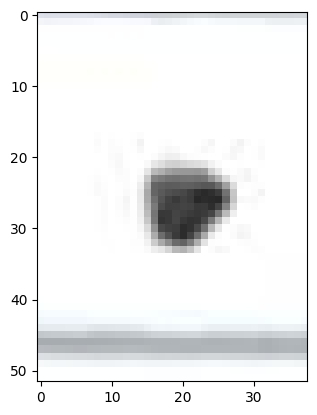

    │           │   ├── Text


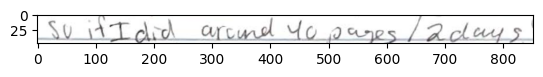

    │           │   ├── Text


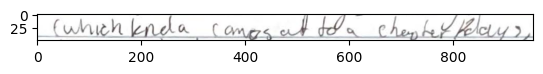

    │           │   └── Text


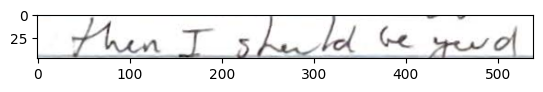

    │           └── Unordered Bullet


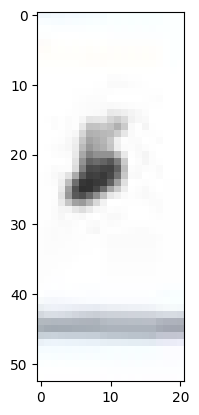

    │               └── Text


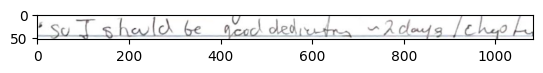

    ├── Header
    │   ├── Text


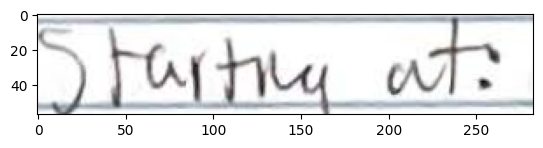

    │   └── Text


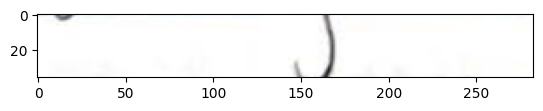

    └── Section
        └── Text


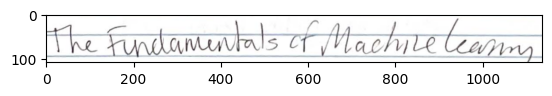

In [78]:
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")
    if not node.is_section:
        plt.imshow(node.img)
        plt.show()

## Text Detection

### Functions

In [79]:
def simple_filter(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    normalized = (255 * (gray / gray.max()))
    return normalized

In [80]:
def is_text(node):
    return node.cls_id == 3

In [97]:
def get_text_prediction(image, model):
    results = model(image)
    result = results[0]
    text = result['generated_text']
    return text.strip()

### Usage

In [98]:
transfer = pipeline("image-to-text", model="microsoft/trocr-base-handwritten")

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cuda:0


In [99]:
for pre, fill, node in RenderTree(root):
    if is_text(node):
        cv2_img = node.img
        pil_img = Image.fromarray(cv2_img) 
        text = get_text_prediction(pil_img, transfer)
        node.text = text

Root
├── Section
│   ├── Text
Hands - on Machine Learning with


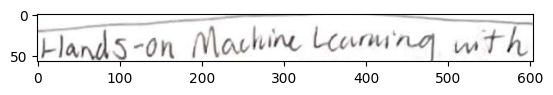

│   └── Text
Sickit-turn , beans , and tensor flour


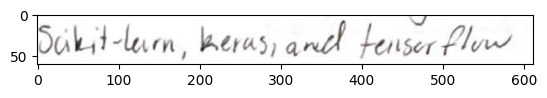

└── Header
    ├── Text
forward


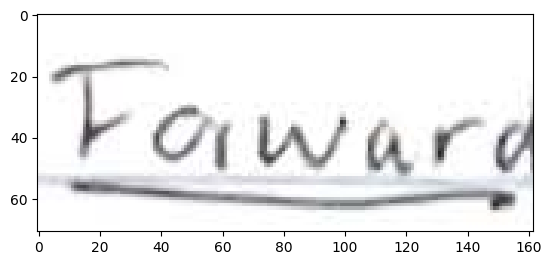

    ├── Section
    │   ├── Text
I want to get the first part of this book done


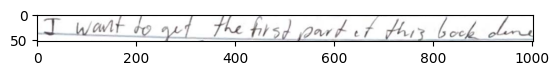

    │   ├── Text
by the end of winter break


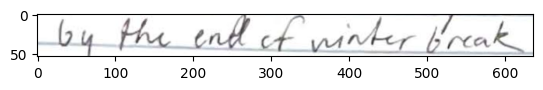

    │   ├── Section
    │   │   ├── Text
trategy for Godball learning


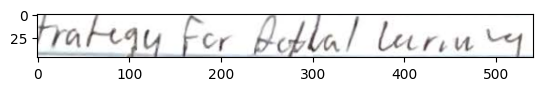

    │   │   ├── Unordered Bullet


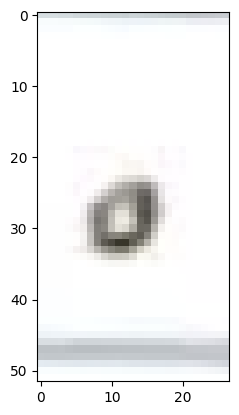

    │   │   │   └── Text
spital when on this daily , or dedicate time


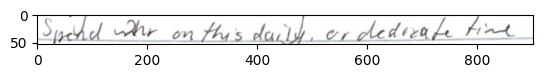

    │   │   ├── Unordered Bullet


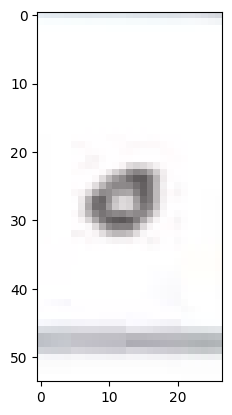

    │   │   │   └── Text
head review questions " before reading


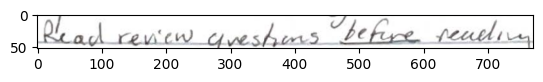

    │   │   ├── Unordered Bullet


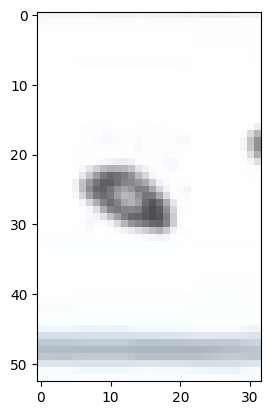

    │   │   │   └── Text
" Take notes in important concepts -


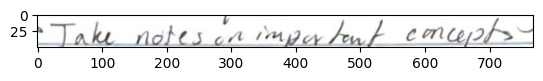

    │   │   └── Unordered Bullet


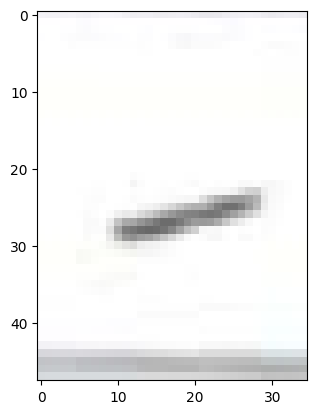

    │   │       ├── Text
-mmbe . . First time Lead through ( hephought )


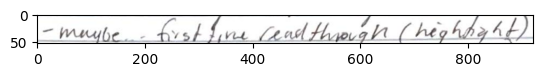

    │   │       └── Text
second time skim-cond-Choles )


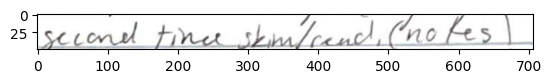

    │   └── Section
    │       └── Unordered Bullet


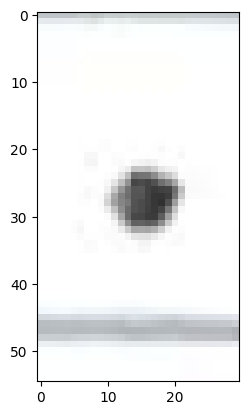

    │           ├── Text
s around 2/5 pages in total , and I


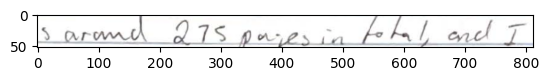

    │           ├── Text
crawl 3 , 3 wickets to the ( US-18 days )


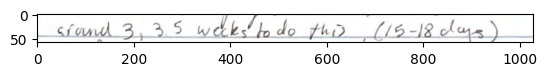

    │           ├── Unordered Bullet


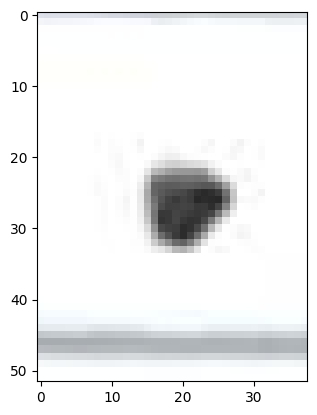

    │           │   ├── Text
svift-Mid round to prices ( 2 days .


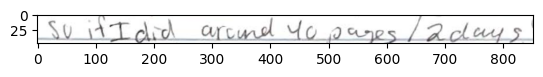

    │           │   ├── Text
finnish knda composted at the Charterteacher ,


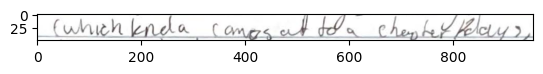

    │           │   └── Text
then I should be good


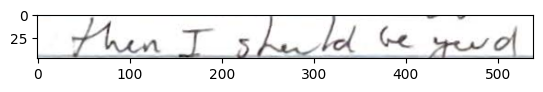

    │           └── Unordered Bullet


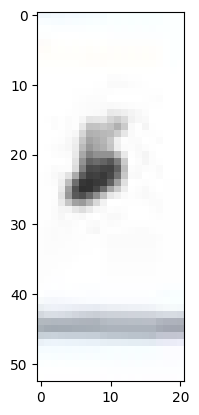

    │               └── Text
so I should be good deductions in 2 days ( cheap to


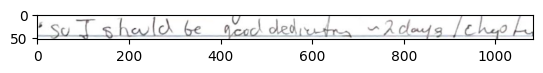

    ├── Header
    │   ├── Text
starting out .


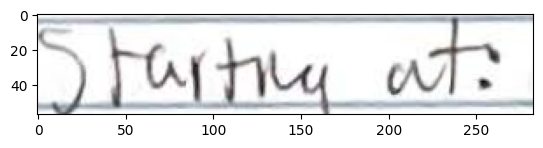

    │   └── Text
't just


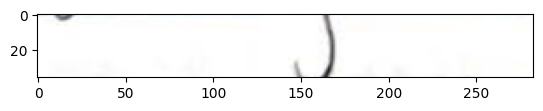

    └── Section
        └── Text
The Fundamentals of Machine learning


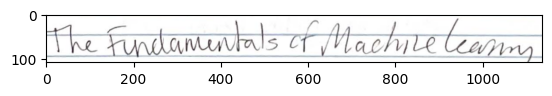

In [101]:
for pre, fill, node in RenderTree(root):
    print(f"{pre}{node.name}")
    if not node.is_section:
        if is_text(node):
            print(node.text)
        plt.imshow(node.img)
        plt.show()

## Tree to Md

### Functions

For parsing, will have to figure out class labels and ids, for now its:

large-sections

0. Header
1. Section

by-line

0. None
1. Unordered Bullet
2. Ordered Bullet
3. Text
4. Figures

In [107]:
def strict_clean_str(text):
    clean_text = re.sub(r"[^a-zA-Z0-9 ]", "", text)
    return clean_text

def lax_clean_str(text):
    # Regex to find common markdown characters
    markdown_chars = r"([\\`*_{}\[\]()#+\-.!|])"
    # Add a backslash before every match
    escaped_text = re.sub(markdown_chars, r"\\\1", text)
    return escaped_text

In [118]:
def markdown_from_nodes(root):
    parts = []

    for node in PreOrderIter(root):
        if node.is_section:
            match node.cls_id:
                case -1: # Root
                    print("Root")
                case 0: # Header
                    parts.append("\n\n# ")
                case 1: # Section
                    parts.append("\n\n")
                case _:
                    print("Unknown Class")
        else:
            match node.cls_id:
                case 0:
                    print("None Class")
                case 1: # Unordered Bullet
                    parts.append("\n- ")
                case 2: # Ordered Bullet
                    parts.append("\n- ")
                case 3: # Text
                    parts.append(node.text)
                    parts.append(" ")
                case 4: # Figure
                    print("Doing nothign with figures for now")
                case _:
                    print("Unknown Class")

    return "".join(parts)

### Usage

In [119]:
md = markdown_from_nodes(root)
md

with open(Path(r".\working\testing.md"), "w") as f:
    f.write(md)

Root
